<a href="https://colab.research.google.com/github/sanvi-g07/ml-zoomcamp/blob/main/ml_zoomcamp_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Get data

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [147]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2026-08-11 00:35:33--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.2’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.001s  

2026-08-11 00:35:33 (56.8 MB/s) - ‘course_lead_scoring.csv.2’ saved [80876/80876]



In [148]:
df = pd.read_csv("course_lead_scoring.csv")

#Data preparation

In [149]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [150]:
df.dtypes

,0
lead_source,object
industry,object
number_of_courses_viewed,int64
annual_income,float64
employment_status,object
location,object
interaction_count,int64
lead_score,float64
converted,int64


In [151]:
df['number_of_courses_viewed'].nunique()

10

In [152]:
df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [153]:
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [154]:
df[numerical].isnull().sum()

,0
number_of_courses_viewed,0
annual_income,181
interaction_count,0
lead_score,0


In [155]:
df[numerical] = df[numerical].fillna(0)

In [156]:
df[numerical].isnull().sum()

,0
number_of_courses_viewed,0
annual_income,0
interaction_count,0
lead_score,0


In [157]:
df[categorical].isnull().sum()

,0
lead_source,128
industry,134
employment_status,100
location,63


In [158]:
df[categorical] = df[categorical].fillna('NA')

In [159]:
df[categorical].isnull().sum()

,0
lead_source,0
industry,0
employment_status,0
location,0


#EDA

In [160]:
df.describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,2.031464,52472.172367,2.976744,0.506108,0.619015
std,1.449717,24254.347030,1.681564,0.288465,0.485795
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,44097.250000,2.000000,0.262500,0.000000
50%,2.000000,57449.500000,3.000000,0.510000,1.000000
75%,3.000000,68241.000000,4.000000,0.750000,1.000000
max,9.000000,109899.000000,11.000000,1.000000,1.000000


In [161]:
for c in categorical:
  display(df[c].value_counts())

,count
lead_source,
organic_search,282
social_media,278
paid_ads,264
referral,260
events,250
NA,128


,count
industry,
retail,203
finance,200
other,198
healthcare,187
education,187
technology,179
manufacturing,174
NA,134


,count
employment_status,
self_employed,352
student,348
unemployed,334
employed,328
NA,100


,count
location,
north_america,225
europe,216
middle_east,198
asia,195
south_america,192
africa,188
australia,185
NA,63


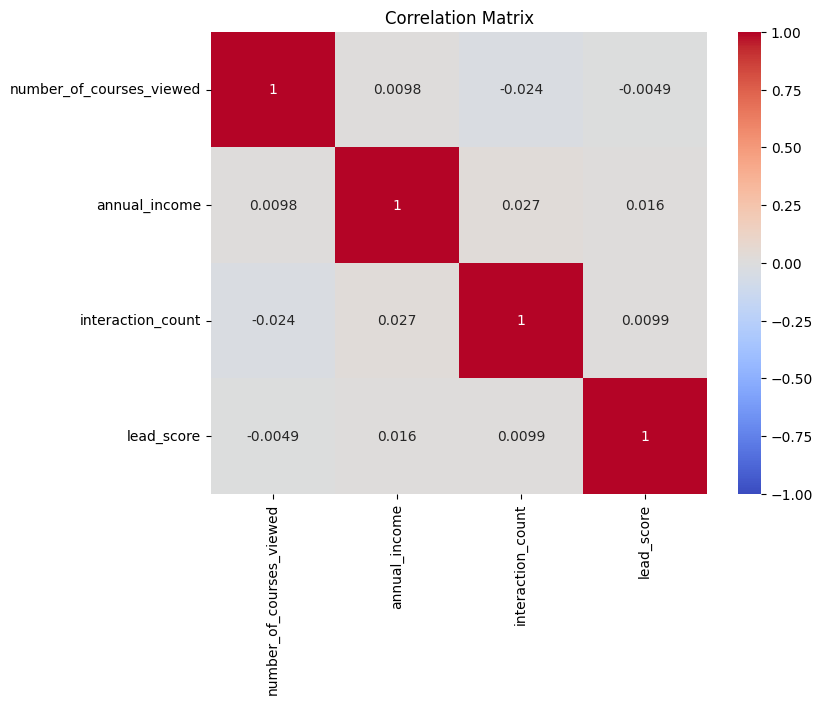

In [162]:
corr_matrix = df[numerical].corr()
corr_matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

#Split data

In [163]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [164]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [165]:
len(df_full_train), len(df_train), len(df_val), len(df_test)

(1169, 876, 293, 293)

In [166]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [167]:
y_full_train = df_full_train['converted']
y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

In [168]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

#Feature importance

## Mutual information score

In [169]:
def mutual_info_converted_score(series):
  return mutual_info_score(series, y_full_train)

In [170]:
mi = round(df_full_train[categorical].apply(mutual_info_converted_score), 2)
mi.sort_values(ascending=False)

,0
lead_source,0.03
industry,0.01
employment_status,0.01
location,0.00


# One Hot Encoding

## Training and validation set

In [171]:
dicts_train = df_train.to_dict(orient='records')
dicts_val = df_val.to_dict(orient='records')

In [172]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dicts_train)
X_val = dv.transform(dicts_val)

In [173]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

# Logistic Regression

In [174]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [175]:
y_val_pred = model.predict_proba(X_val)[:, 1]

In [176]:
converted_decision = (y_val_pred > 0.5).astype(int)
converted_decision

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0])

In [177]:
accuracy = round((y_val == converted_decision).mean(), 2)
accuracy

np.float64(0.7)

#Feature Elimination

In [178]:
all_features = list(df.columns.values)
all_features.remove('converted')
all_features

['lead_source',
 'industry',
 'number_of_courses_viewed',
 'annual_income',
 'employment_status',
 'location',
 'interaction_count',
 'lead_score']

In [179]:
all_feature_acc = accuracy
all_feature_acc

np.float64(0.7)

In [180]:
for f in all_features:
  # Remove a feature
  features = all_features.copy()
  features.remove(f)
  print("Removed feature: ", f)
  df_reduced_train = df_train[features]
  df_reduced_val = df_val[features]

  # One Hot Encoding
  dicts_reduced_train = df_reduced_train.to_dict(orient='records')
  dicts_reduced_val = df_reduced_val.to_dict(orient='records')
  dv = DictVectorizer(sparse=False)
  X_reduced_train = dv.fit_transform(dicts_reduced_train)
  X_reduced_val = dv.transform(dicts_reduced_val)

  # Train model
  model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
  model.fit(X_reduced_train, y_train)

  # Make predictions and print accuracy
  y_val_pred = model.predict_proba(X_reduced_val)[:, 1]
  converted_decision = (y_val_pred > 0.5).astype(int)
  accuracy = round((y_val == converted_decision).mean(), 4)
  print("Accuracy: ", accuracy)
  print("Accuracy Difference: ", (all_feature_acc - accuracy))

  print()

Removed feature:  lead_source
Accuracy:  0.7031
Accuracy Difference:  -0.0030999999999999917

Removed feature:  industry
Accuracy:  0.6997
Accuracy Difference:  0.00029999999999996696

Removed feature:  number_of_courses_viewed
Accuracy:  0.5563
Accuracy Difference:  0.14369999999999994

Removed feature:  annual_income
Accuracy:  0.8532
Accuracy Difference:  -0.1532

Removed feature:  employment_status
Accuracy:  0.6962
Accuracy Difference:  0.0037999999999999146

Removed feature:  location
Accuracy:  0.7099
Accuracy Difference:  -0.00990000000000002

Removed feature:  interaction_count
Accuracy:  0.5563
Accuracy Difference:  0.14369999999999994

Removed feature:  lead_score
Accuracy:  0.7065
Accuracy Difference:  -0.006500000000000061



# Regularized Logistic Regression

In [181]:
for c in [0.01, 0.1, 1, 10, 100]:
  model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
  model.fit(X_train, y_train)
  y_val_pred = model.predict_proba(X_val)[:, 1]
  converted_decision = (y_val_pred > 0.5).astype(int)
  accuracy = round((y_val == converted_decision).mean(), 4)
  print(c, accuracy)

0.01 0.6997
0.1 0.6997
1 0.6997
10 0.6997
100 0.6997
